# Malaria Incidence Prediction — Zimbabwe
Random Forest model trained on WHO malaria indicators (2000–2024).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

In [3]:
df = pd.read_csv('malaria_indicators_zwe.csv')
df = df[df['Numeric'].notna()]
df.rename(columns={'GHO (CODE)': 'GHO_CODE'}, inplace=True)
df.shape

(132, 17)

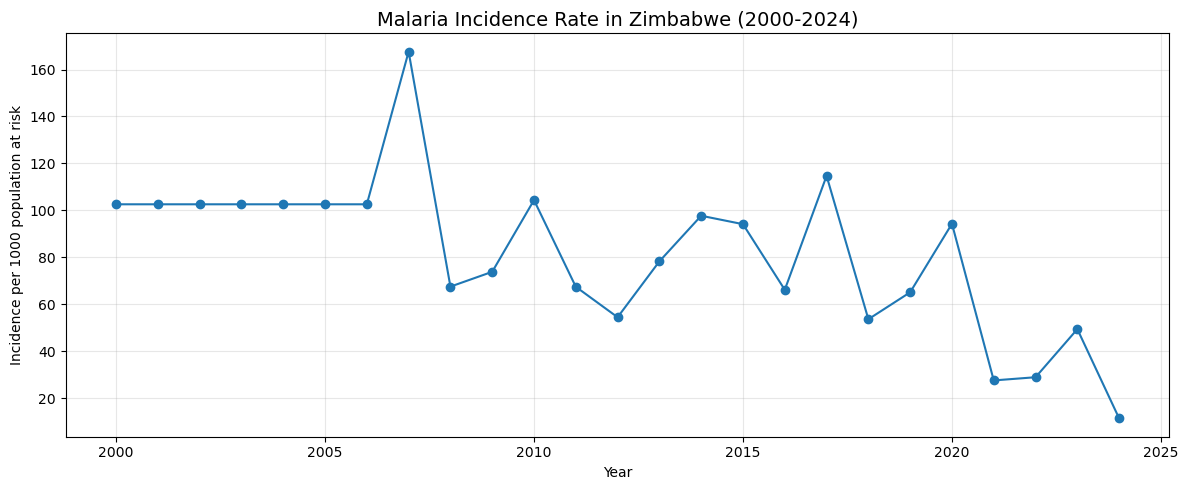

In [4]:
incidence_data = df[df['GHO_CODE'] == 'MALARIA_EST_INCIDENCE'].copy()
incidence_data = incidence_data.sort_values('STARTYEAR')

plt.figure(figsize=(12,5))
plt.plot(incidence_data['STARTYEAR'], incidence_data['Numeric'], marker='o', linestyle='-')
plt.title('Malaria Incidence Rate in Zimbabwe (2000-2024)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Incidence per 1000 population at risk')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
indicators = ['MALARIA_EST_INCIDENCE', 'MALARIA_EST_MORTALITY',
              'MALARIA_CONF_CASES', 'MALARIA_SUSPECTS',
              'MALARIA_RDT_POS', 'MALARIA_IMPORTED']

# FIX: pivot_table handles duplicate (STARTYEAR, GHO_CODE) pairs via mean aggregation
pivoted = df[df['GHO_CODE'].isin(indicators)].pivot_table(
    index='STARTYEAR', columns='GHO_CODE', values='Numeric', aggfunc='mean'
)
pivoted.head()

GHO_CODE,MALARIA_CONF_CASES,MALARIA_EST_INCIDENCE,MALARIA_EST_MORTALITY,MALARIA_IMPORTED,MALARIA_RDT_POS,MALARIA_SUSPECTS
STARTYEAR,,,,,,
2000,NaN,102.588443,26.259795,NaN,NaN,NaN
2001,NaN,102.588544,26.254381,NaN,NaN,NaN
2002,NaN,102.588488,26.255119,NaN,NaN,NaN
2003,NaN,102.588532,26.256063,NaN,NaN,NaN
2004,NaN,102.588516,26.260008,NaN,NaN,NaN


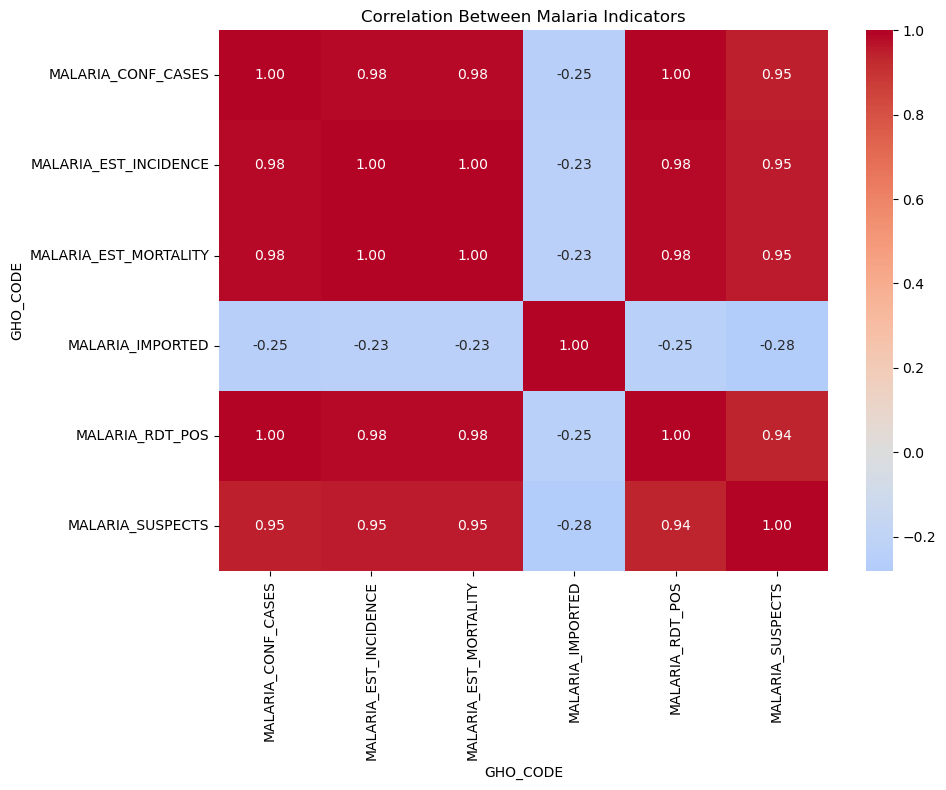

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(pivoted.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Between Malaria Indicators')
plt.tight_layout()
plt.show()

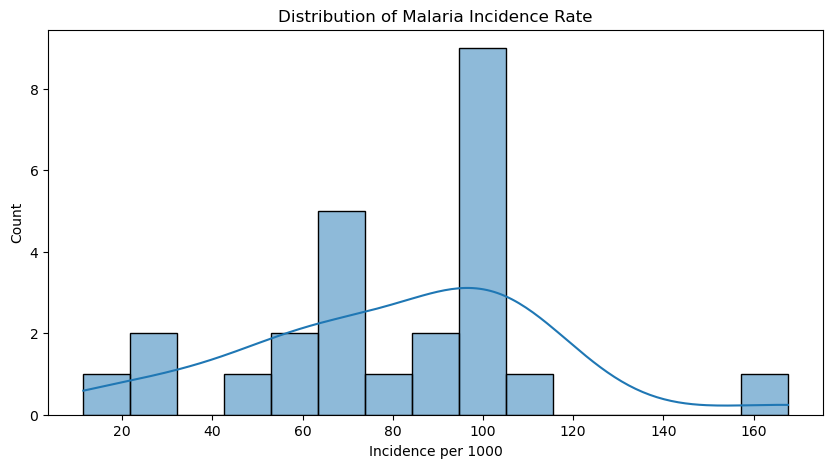

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(pivoted['MALARIA_EST_INCIDENCE'].dropna(), bins=15, kde=True)
plt.title('Distribution of Malaria Incidence Rate')
plt.xlabel('Incidence per 1000')
plt.show()

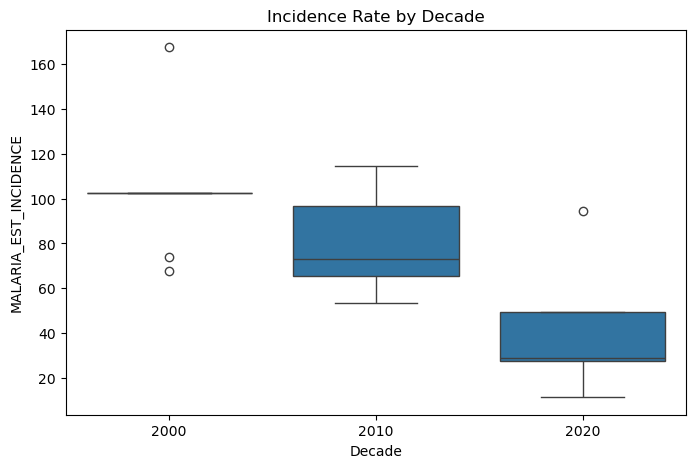

In [8]:
pivoted['Decade'] = (pivoted.index // 10) * 10
plt.figure(figsize=(8,5))
sns.boxplot(data=pivoted, x='Decade', y='MALARIA_EST_INCIDENCE')
plt.title('Incidence Rate by Decade')
plt.show()

In [9]:
# Lag features
for col in indicators:
    if col in pivoted.columns:
        for lag in [1, 2]:
            pivoted[f'{col}_lag{lag}'] = pivoted[col].shift(lag)

# Cyclic year encoding
pivoted['year_sin'] = np.sin(2 * np.pi * pivoted.index / 4)
pivoted['year_cos'] = np.cos(2 * np.pi * pivoted.index / 4)

In [10]:
target = 'MALARIA_EST_INCIDENCE'
pivoted = pivoted.dropna(subset=[target])

feature_cols = [c for c in pivoted.columns if c not in [target, 'Decade']]
X = pivoted[feature_cols].fillna(pivoted[feature_cols].median())
y = pivoted[target]

print(f"Features: {len(feature_cols)}, Samples: {len(X)}")

Features: 19, Samples: 25


In [11]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

In [12]:
train_mask = X_scaled.index < 2016
X_train, X_test = X_scaled[train_mask], X_scaled[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]
print(f"Train: {len(X_train)} years, Test: {len(X_test)} years")

Train: 16 years, Test: 9 years


In [13]:
tscv = TimeSeriesSplit(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_scaled)):
    print(f"Fold {fold+1}: Train {X_scaled.index[train_idx][0]}–{X_scaled.index[train_idx][-1]}, "
          f"Test {X_scaled.index[test_idx][0]}–{X_scaled.index[test_idx][-1]}")

Fold 1: Train 2000–2004, Test 2005–2008
Fold 2: Train 2000–2008, Test 2009–2012
Fold 3: Train 2000–2012, Test 2013–2016
Fold 4: Train 2000–2016, Test 2017–2020
Fold 5: Train 2000–2020, Test 2021–2024


In [14]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"Model Performance on Test Set:")
print(f"  MAE:  {mae:.2f}  (incidence per 1000)")
print(f"  RMSE: {rmse:.2f}")
print(f"  R²:   {r2:.3f}")

Model Performance on Test Set:
  MAE:  20.55  (incidence per 1000)
  RMSE: 26.90
  R²:   0.250


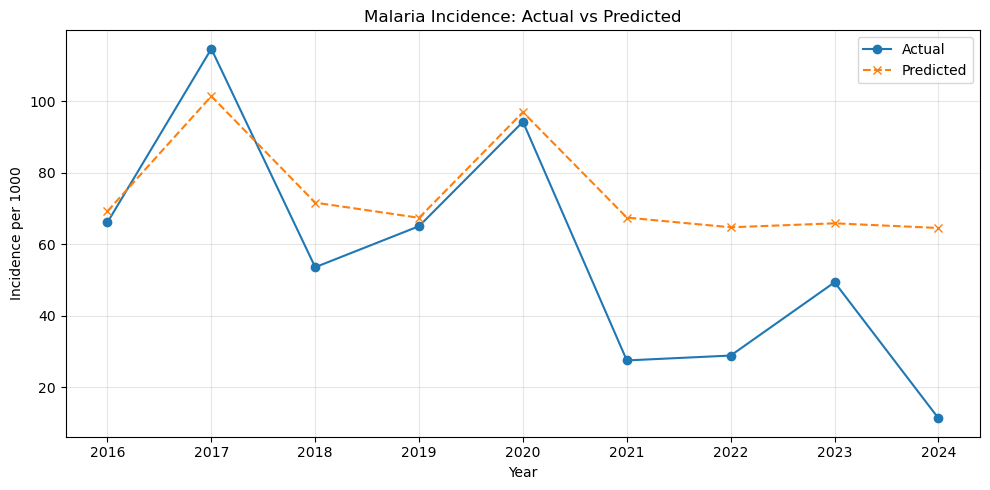

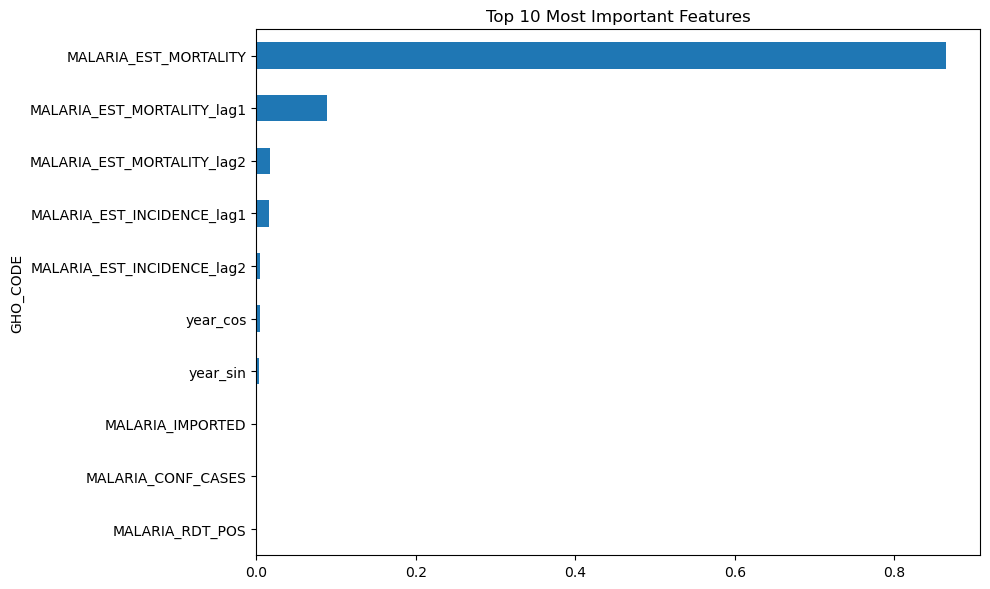

In [15]:
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test.values, marker='o', label='Actual')
plt.plot(y_test.index, y_pred, marker='x', linestyle='--', label='Predicted')
plt.title('Malaria Incidence: Actual vs Predicted')
plt.xlabel('Year')
plt.ylabel('Incidence per 1000')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importances.head(10).plot(kind='barh')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Save Model Artifacts
Save the trained model, scaler, and feature metadata together so the Streamlit app can load them correctly.

In [16]:
# FIX: Save model + scaler + feature list as a single artifact bundle
artifacts = {
    'model': model,
    'scaler': scaler,
    'feature_cols': feature_cols,
    'feature_medians': X.median().to_dict()   # used to fill unseen lag features in the app
}
with open('malaria_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Saved malaria_model.pkl — ready for the Streamlit app.")

Saved malaria_model.pkl — ready for the Streamlit app.
